# Liftoff robustness — full-spectrum dense models vs the ZCF baseline

`data/raw/liftoff_sweep.csv` is a COMSOL sweep of sensor standoff from 20 to 80 mm at a
**fixed, unlabelled material**. Both inversion methods were built at the nominal 40 mm
liftoff. This notebook asks what each one does when the standoff moves.

Nothing is retrained. The four dense estimators and the training-fitted scaler are loaded
from `models/`, exported by Block 8 of `full_spectrum/dense_models.ipynb`; the ZCF baseline
is calibrated on the same clean dense grid it always was.

**Protocol**

1. Recover the material by matching the 40 mm spectrum against the dense and FE grids.
   If nothing matches, the experiment does not exist and the notebook stops here.
2. Build ΔL = L₂ − L₃ per liftoff, reshape to the 16-feature vector in the training
   column order, and report how far each standoff sits from nominal.
3. Predict with the already-fitted models; predict with ZCF on the same sweep.
4. Report absolute APE against the known target **and** the shift relative to the 40 mm
   nominal prediction — the 40 mm row is itself already wrong for the dense models (the
   known FE transfer gap), so the two effects have to be separated or the study says
   nothing new about liftoff.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

project_root = Path.cwd().parents[1]
sys.path.insert(0, str(project_root))

fig_dir = project_root / 'figures' / 'robustness'
fig_dir.mkdir(parents=True, exist_ok=True)

from src.data import load_data, load_raw, rename_columns, compute_differential
from src.robustness import (load_liftoff_sweep, to_wide_features, zcf_table,
                            predict_mu_given_rho, predict_rho_given_mu)

MODEL_DIR = project_root / 'models'
FINAL  = joblib.load(MODEL_DIR / 'final_models.joblib')
SCALER = joblib.load(MODEL_DIR / 'train_scaler.joblib')   # diagnostic ONLY -- see below
SPEC   = joblib.load(MODEL_DIR / 'feature_spec.joblib')

H            = SPEC['H']
SELECTED     = SPEC['selected']
RANGE_BOUNDS = SPEC['range_bounds']

# Every estimator in FINAL is TransformedTargetRegressor(GridSearchCV(Pipeline([...
# StandardScaler ...]))) and scales internally. Predictions are therefore taken on the
# RAW 16-column frame, exactly as Block 5 of dense_models.ipynb does. SCALER is used
# only for the SD-displacement diagnostic; pre-scaling with it would double-scale.
MODELS = sorted({n for _, n in FINAL})

train = load_data('train.xlsx')
test  = load_data('test.xlsx')

print('models loaded :', MODELS)
print('selected      :', SELECTED)
print('features      :', H[:2], '...', H[-2:], f'({len(H)})')

models loaded : ['GPR (Matern 1.5)', 'GPR (Matern 2.5)', 'Poly2+Ridge', 'kNN (PCA-4)']
selected      : GPR (Matern 2.5)
features      : ['H_imag_375', 'H_imag_750'] ... ['H_real_24000', 'H_real_48000'] (16)


## 1 — Which material is this?

`liftoff_sweep.csv` carries no `permeability` / `resistivity` columns, so the material has
to be recovered before anything else can be interpreted. The 40 mm spectrum is matched
against both grids in standardised feature space, using the training-fitted scaler.

Two reference scales make the distances readable:

- **0.268 SD** — the dense grid's own nearest-neighbour spacing. A match closer than this
  is inside one grid cell.
- **0.505 SD** — the median dense↔FE displacement at shared materials (the forward-model
  transfer gap measured in `dense_models.ipynb` Block 7b).

In [2]:
GRID_SPACING, TRANSFER_GAP = 0.268, 0.505

lo_long = load_liftoff_sweep()
LIFTOFFS = np.sort(lo_long['liftoff'].unique())
W = to_wide_features(lo_long, ['liftoff'], H)
assert list(W.columns[1:]) == H, 'feature order does not match H'

Zw  = SCALER.transform(W[H])
v40 = Zw[list(W['liftoff']).index(40)]

print(f'liftoff sweep: {lo_long.shape} long -> {W.shape} wide '
      f'| standoffs {LIFTOFFS.tolist()} mm\n')

nearest = {}
for label, df in [('dense (train)', train), ('FE (test)', test)]:
    d = np.linalg.norm(SCALER.transform(df[H]) - v40, axis=1)
    k = np.argsort(d)[:3]
    print(f'  nearest in {label}:')
    for r, i in enumerate(k):
        print(f'    mu_r={df.permeability.iloc[i]:>9.3f}  rho={df.resistivity.iloc[i]:.2e}'
              f'   {d[i]:7.3f} SD' + ('   <-- best' if r == 0 else ''))
    nearest[label] = (df.permeability.iloc[k[0]], df.resistivity.iloc[k[0]], d[k[0]])

MU_TRUE, RHO_TRUE, d_fe = nearest['FE (test)']
MU_TRUE = float(MU_TRUE)

assert d_fe < GRID_SPACING, (
    f'40 mm spectrum matches nothing on either grid (best {d_fe:.3f} SD > {GRID_SPACING} SD) '
    '-- this experiment does not exist; stop here.')

print(f'\n  --> identified: mu_r = {MU_TRUE:g}, rho = {RHO_TRUE:.1e} ohm.m at {d_fe:.3f} SD')
print(f'      inside the {GRID_SPACING} SD grid cell, and below the {TRANSFER_GAP} SD transfer gap.')
print( '      The liftoff sweep is an FE export, as the test set is; the residual is mesh/')
print( '      version drift between two COMSOL .mph files of the same model.')

liftoff sweep: (56, 6) long -> (7, 17) wide | standoffs [20, 30, 40, 50, 60, 70, 80] mm

  nearest in dense (train):
    mu_r=  133.352  rho=3.00e-07     0.231 SD   <-- best
    mu_r=  100.000  rho=4.00e-07     0.323 SD
    mu_r=   74.989  rho=5.00e-07     0.440 SD
  nearest in FE (test):
    mu_r=  200.000  rho=2.00e-07     0.134 SD   <-- best
    mu_r=  100.000  rho=4.00e-07     0.318 SD
    mu_r=  100.000  rho=6.00e-07     0.844 SD

  --> identified: mu_r = 200, rho = 2.0e-07 ohm.m at 0.134 SD
      inside the 0.268 SD grid cell, and below the 0.505 SD transfer gap.
      The liftoff sweep is an FE export, as the test set is; the residual is mesh/
      version drift between two COMSOL .mph files of the same model.


**How strong is that identification?** Two pieces of evidence, and one that looks like
evidence but is not.

*The margin.* In standardised differential space the chosen FE material sits **2.37× closer**
than the next FE candidate (0.134 SD vs 0.318 SD). That is the real discriminator.

*Independent corroboration.* The ZCF baseline — which uses only the zero crossing, not the
amplitude, and so fails completely differently from a distance match — returns μᵣ = 205.7
given ρ = 2e-7, and ρ = 2.042e-7 given μᵣ = 200. Both within 3% of the claimed identity.
Each is conditional on the other, so this corroborates rather than proves, but the two
methods agreeing is far stronger than either alone.

*What is NOT evidence:* raw coil-level agreement. The 40 mm row matches FE (200, 2e-7) to a
median 0.049% on the raw inductances — but it also matches dense (133.352, 3e-7) to 0.048%
and FE (100, 4e-7) to 0.045%. The coil inductance is dominated by a material-independent
term (|L| ≈ 6e-4 across the whole grid, while the differential |H| runs down to 1e-6), so
agreement at the coil level cannot discriminate between materials at all. Only the maximum
relative error separates them (10.2% for the chosen material against 32.7% and 33.0%), and
that is a much weaker signal than the differential-space margin.

Note where this material sits: **ρ = 2e-7 Ω·m is the minimum of the calibration range**
(`RANGE_BOUNDS` 2e-7 … 1e-6) and μᵣ = 200 is mid-range. That matters for reading the ZCF
results later — `np.interp` clamps at the ends of the calibration grid, so a resistivity
prediction that runs off the bottom lands exactly on the true value **for free**.

## 2 — How far off-manifold does liftoff push the spectrum?

Before any prediction: the displacement of each standoff from the 40 mm spectrum, in the
same standardised units.

In [3]:
disp = pd.DataFrame({
    'liftoff_mm': LIFTOFFS,
    'SD_from_40mm': [np.linalg.norm(Zw[i] - v40) for i in range(len(W))],
})
disp['x_grid_spacing'] = disp['SD_from_40mm'] / GRID_SPACING
disp['regime'] = np.where(disp.SD_from_40mm == 0, 'nominal',
                  np.where(disp.SD_from_40mm < GRID_SPACING, 'within one grid cell',
                           'extrapolation'))
display(disp.style.format({'SD_from_40mm': '{:.2f}', 'x_grid_spacing': '{:.1f}x'})
                  .hide(axis='index'))

print(f'Every off-nominal standoff sits {disp[disp.liftoff_mm != 40].SD_from_40mm.min():.1f}-'
      f'{disp.SD_from_40mm.max():.1f} SD from nominal, against a grid spacing of {GRID_SPACING} SD.')
print('The dense models are being asked to extrapolate 18-90 grid cells beyond their support.')
print('Failure there is the expected result, not a bug -- the question is the shape of it.')

liftoff_mm,SD_from_40mm,x_grid_spacing,regime
20,24.06,89.8x,extrapolation
30,8.25,30.8x,extrapolation
40,0.00,0.0x,nominal
50,4.82,18.0x,extrapolation
60,7.81,29.1x,extrapolation
70,9.78,36.5x,extrapolation
80,11.10,41.4x,extrapolation


Every off-nominal standoff sits 4.8-24.1 SD from nominal, against a grid spacing of 0.268 SD.
The dense models are being asked to extrapolate 18-90 grid cells beyond their support.
Failure there is the expected result, not a bug -- the question is the shape of it.


## 3 — Dense-model predictions

All four estimators, both targets, on the raw 16-column frame.

Following `dense_models.ipynb`, **nothing is clipped**. Predictions outside `RANGE_BOUNDS`
are counted and flagged, not repaired, so a model leaving its supported region stays visible.

In [4]:
rows = []
for (target, name), mdl in FINAL.items():
    pred = mdl.predict(W[H])                    # raw frame; the pipeline scales internally
    for L, p, z in zip(W['liftoff'], pred, Zw):
        rows.append(dict(liftoff=int(L), method=name, target=target, pred=float(p),
                         sd_from_40mm=float(np.linalg.norm(z - v40))))

R = pd.DataFrame(rows)
R['truth'] = np.where(R.target == 'permeability', MU_TRUE, RHO_TRUE)
R['ape']   = (R.pred - R.truth).abs() / R.truth * 100

lo_b = R.target.map(lambda t: RANGE_BOUNDS[t][0])
hi_b = R.target.map(lambda t: RANGE_BOUNDS[t][1])
R['outside_support'] = (R.pred < lo_b) | (R.pred > hi_b)

print('Predictions outside the fitted range (counted, never clipped):')
for name in MODELS:
    s = R[R.method == name]
    print(f'  {name:18s} {s.outside_support.sum():>2}/{len(s)}'
          f'   worst APE {s.ape.max():.4g}%')

Predictions outside the fitted range (counted, never clipped):
  GPR (Matern 1.5)   12/14   worst APE 5.753e+04%
  GPR (Matern 2.5)    8/14   worst APE 3.688e+04%
  Poly2+Ridge        14/14   worst APE 2.276e+25%
  kNN (PCA-4)         0/14   worst APE 400%


## 4 — The ZCF baseline on the same sweep

Same protocol as `zcf_baseline/01_zcf.ipynb`: extract the zero crossing of `H_real` in
log-frequency, then invert conditionally against the clean dense calibration grid — each
target predicted given the true value of the other.

ρ = 2e-7 is exactly a dense grid column, so `predict_mu_given_rho` reads a real calibration
column rather than an interpolated one.

Every prediction is checked for **clamping**: `np.interp` saturates at the ends of the
calibration grid, and a clamped prediction is a refusal to extrapolate, not a measurement.

In [5]:
dense_long = compute_differential(rename_columns(load_raw('train.xlsx')))
CALIB = zcf_table(dense_long)
RHOS  = np.sort(CALIB['resistivity'].unique())
MU_GRID = np.sort(CALIB['permeability'].unique())

ZL = zcf_table(compute_differential(lo_long.copy()), ['liftoff'])
ZL['delta_pct'] = (ZL.z / float(ZL.loc[ZL.liftoff == 40, 'z'].iloc[0]) - 1) * 100

print('Zero-crossing frequency vs standoff:')
display(ZL.style.format({'z': '{:.1f} Hz', 'delta_pct': '{:+.1f}%'}).hide(axis='index'))

EDGE = {'permeability': (MU_GRID.min(), MU_GRID.max()),
        'resistivity':  (RHOS.min(), RHOS.max())}

zcf_rows = []
for _, r in ZL.iterrows():
    preds = {'permeability': predict_mu_given_rho(r.z, RHO_TRUE, CALIB),
             'resistivity':  predict_rho_given_mu(r.z, MU_TRUE, CALIB, RHOS)}
    for target, p in preds.items():
        truth = MU_TRUE if target == 'permeability' else RHO_TRUE
        # np.interp returns the endpoint EXACTLY when it clamps, so this is an
        # equality test. atol must be 0: the default 1e-8 is two orders of magnitude
        # larger than rho itself (~1e-7) and would flag every rho prediction as clamped.
        clamped = bool(np.isclose(p, EDGE[target][0], rtol=1e-12, atol=0.0) or
                       np.isclose(p, EDGE[target][1], rtol=1e-12, atol=0.0))
        zcf_rows.append(dict(liftoff=int(r.liftoff), method='ZCF (conditional)', target=target,
                             pred=float(p), sd_from_40mm=np.nan, truth=truth,
                             ape=abs(p - truth) / truth * 100,
                             outside_support=False, clamped=clamped))

R['clamped'] = False
R = pd.concat([R, pd.DataFrame(zcf_rows)], ignore_index=True)

# Shift relative to the 40 mm nominal prediction, per method and target.
nominal = R[R.liftoff == 40].set_index(['method', 'target'])['ape']
R['ape_at_40mm'] = pd.MultiIndex.from_frame(R[['method', 'target']]).map(nominal)
R['delta_vs_nominal'] = R.ape - R.ape_at_40mm

n_clamped = R.clamped.sum()
print(f'\nZCF predictions clamped at a calibration-grid edge: {n_clamped}/{len(zcf_rows)}')
print('Those are saturation, not accuracy -- read them as "off the scale", never as a score.')

Zero-crossing frequency vs standoff:


liftoff,z,delta_pct
20,470.1 Hz,-37.5%
30,666.2 Hz,-11.4%
40,752.0 Hz,+0.0%
50,771.5 Hz,+2.6%
60,782.1 Hz,+4.0%
70,788.2 Hz,+4.8%
80,791.9 Hz,+5.3%



ZCF predictions clamped at a calibration-grid edge: 6/14
Those are saturation, not accuracy -- read them as "off the scale", never as a score.


## 5 — Results

Absolute APE against the recovered target, with the shift from the 40 mm nominal in
brackets. `*` marks a ZCF prediction clamped at a calibration-grid edge.

In [6]:
ORDER = MODELS + ['ZCF (conditional)']

def panel(target):
    s = R[R.target == target]
    cell = s.assign(txt=[f"{a:,.2f}{'*' if c else ''} [{d:+,.2f}]"
                         for a, c, d in zip(s.ape, s.clamped, s.delta_vs_nominal)])
    out = cell.pivot(index='liftoff', columns='method', values='txt')[ORDER]
    out.index = [f'{i} mm' + ('  (nominal)' if i == 40 else '') for i in out.index]
    return out

for target in ['permeability', 'resistivity']:
    truth = MU_TRUE if target == 'permeability' else RHO_TRUE
    print(f'--- {target}   true = {truth:g}   |   APE %  [shift vs 40 mm, pp] ---')
    display(panel(target))

print('* = clamped at a calibration-grid edge (saturated, not accurate)')

--- permeability   true = 200   |   APE %  [shift vs 40 mm, pp] ---


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
20 mm,99.99 [+48.31],85.05 [+33.26],"22,764,829,523,842,101,690,761,216.00 [+22,764...",33.34 [-6.18],400.00* [+397.15]
30 mm,100.00 [+48.31],99.32 [+47.53],"1,884,895.29 [+1,881,260.37]",54.55 [+15.04],213.21 [+210.36]
40 mm (nominal),51.68 [+0.00],51.79 [+0.00],"3,634.92 [+0.00]",39.52 [+0.00],2.85 [+0.00]
50 mm,"54,404.56 [+54,352.87]","36,875.24 [+36,823.45]","10,682.33 [+7,047.41]",314.39 [+274.88],31.04 [+28.19]
60 mm,"57,530.61 [+57,478.92]","4,750.54 [+4,698.75]","74,037.99 [+70,403.06]",400.00 [+360.48],43.74 [+40.89]
70 mm,"32,893.68 [+32,842.00]",805.61 [+753.82],"379,739.13 [+376,104.21]",400.00 [+360.48],49.84 [+46.99]
80 mm,"20,948.25 [+20,896.57]",247.49 [+195.70],"1,183,544.84 [+1,179,909.92]",400.00 [+360.48],53.25 [+50.41]


--- resistivity   true = 2e-07   |   APE %  [shift vs 40 mm, pp] ---


method,GPR (Matern 1.5),GPR (Matern 2.5),Poly2+Ridge,kNN (PCA-4),ZCF (conditional)
20 mm,"6,500.28 [+6,389.78]",234.48 [+100.36],"53,178.06 [+37,428.02]",81.25 [-12.50],400.00* [+397.90]
30 mm,"3,683.11 [+3,572.62]","1,373.91 [+1,239.79]","27,278.26 [+11,528.22]",81.25 [-12.50],165.44 [+163.34]
40 mm (nominal),110.50 [+0.00],134.12 [+0.00],"15,750.04 [+0.00]",93.75 [+0.00],2.10 [+0.00]
50 mm,"1,349.84 [+1,239.35]","1,078.89 [+944.77]","9,330.96 [-6,419.07]",293.75 [+200.00],0.00* [-2.10]
60 mm,"1,788.49 [+1,677.99]","1,009.80 [+875.68]","5,467.52 [-10,282.52]",318.75 [+225.00],0.00* [-2.10]
70 mm,"1,975.19 [+1,864.69]",807.00 [+672.88],"2,994.92 [-12,755.12]",318.75 [+225.00],0.00* [-2.10]
80 mm,"2,063.27 [+1,952.78]",645.17 [+511.05],"1,447.67 [-14,302.36]",318.75 [+225.00],0.00* [-2.10]


* = clamped at a calibration-grid edge (saturated, not accurate)


### Reading these numbers

**At 40 mm the dense models are already wrong.** GPR (Matern 2.5) sits at ~52% on μᵣ and
~134% on ρ before the standoff moves at all. That is the known forward-model transfer gap,
not a liftoff effect, and it is exactly why the bracketed column exists.

**Off nominal, the dense models do not degrade — they break.** APEs run to 10³–10⁴% and,
for Poly2+Ridge, to 10²⁵%. At 4.8–24 SD outside a grid whose spacing is 0.268 SD, the
kernel has nothing to interpolate between and the polynomial is unbounded. The kNN floor
is the mild case only because it cannot leave the convex hull of its training targets — it
saturates at μᵣ = 1000 (APE 400%) rather than diverging.

**ZCF degrades gracefully upward and collapses downward**, tracking the zero crossing
itself: −37.5% at 20 mm against +5.3% at 80 mm. The physics is that a zero crossing is a
*shape* feature of the spectrum, and increasing standoff attenuates the signal roughly
uniformly, which moves the crossing very little. Reducing standoff changes the coupling
geometry and moves it a lot.

**The one result that must not be oversold** is ZCF's ρ column above 40 mm. It reads
0.00%, and it is clamping: the true ρ = 2e-7 is the *minimum* of the calibration grid, so
every prediction that runs off the bottom lands on the right answer by construction. A
material in the middle of the ρ range would not get this. Those cells are marked `*` and
carry no evidence.

### Two limits on the head-to-head comparison

**ZCF is scored conditionally; the dense models are not.** Every ZCF number above is
produced knowing the true value of the other property — μᵣ inverted given ρ = 2e-7, ρ given
μᵣ = 200. The dense models are given only the spectrum. ZCF therefore has information they
do not, and its margin at 40 mm (2.9% against 52%) overstates the like-for-like gap by an
unknown amount. The same caveat is recorded in `zcf_baseline/01_zcf.ipynb`.

**This is one material, at n = 1 per standoff.** `liftoff_sweep.csv` sweeps standoff at a
single fixed (μᵣ, ρ), so every cell in the tables above is a single absolute percentage
error, not an average over materials. The *shape* of the two degradation curves is clear
and mechanistically explicable, but the magnitudes should not be read as calibrated
error rates, and nothing here establishes that the ordering holds across the material grid.
Confirming that needs an FE liftoff sweep at several materials — ideally including one in
the interior of the ρ range, which would also remove the clamping artefact above.

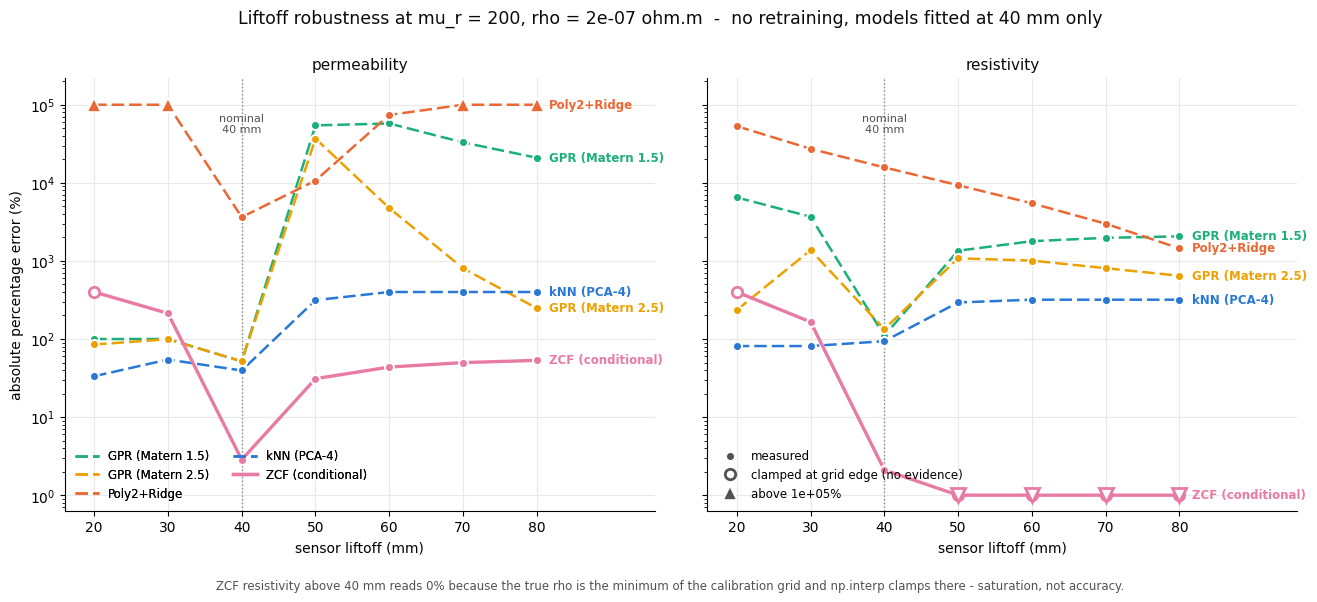

In [7]:
# Display window. Below 1% nothing is real accuracy -- the only sub-1% cells are ZCF
# resistivity predictions clamped at the grid edge, which score 0% by construction.
# Letting them fall to the axis floor would draw saturation as near-perfection, so
# they are pinned to the floor and drawn with the clamped marker instead.
FLOOR, CEIL = 1.0, 1e5

PALETTE = {'kNN (PCA-4)':      '#2a78d6',
           'Poly2+Ridge':      '#eb6834',
           'GPR (Matern 1.5)': '#1baf7a',
           'GPR (Matern 2.5)': '#eda100',
           'ZCF (conditional)':'#e87ba4'}

def stagger(vals, min_sep=0.13):
    # Nudge direct labels apart in log space so end-of-line labels do not collide.
    out = list(vals)
    for i in np.argsort(vals):
        for j in np.argsort(vals):
            if i != j and 0 < out[i] and abs(np.log10(out[i]) - np.log10(out[j])) < min_sep:
                if out[i] <= out[j]:
                    out[i] = 10 ** (np.log10(out[j]) - min_sep)
    return out

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6), sharey=True)

for ax, target in zip(axes, ['permeability', 'resistivity']):
    ends = {}
    for name in ORDER:
        s = R[(R.target == target) & (R.method == name)].sort_values('liftoff')
        y = s.ape.to_numpy().clip(FLOOR, CEIL)
        x = s.liftoff.to_numpy()
        is_zcf = name.startswith('ZCF')
        col = PALETTE[name]

        ax.plot(x, y, lw=2.4 if is_zcf else 1.8, color=col,
                ls='-' if is_zcf else (0, (5, 2)), zorder=3 if is_zcf else 2,
                label=name)

        clamped = s.clamped.to_numpy()
        over    = s.ape.to_numpy() > CEIL
        under   = s.ape.to_numpy() < FLOOR
        plain   = ~(clamped | over | under)

        # honest marks: filled = a real measurement, open = saturated at a grid edge,
        # triangle = off the axis in that direction
        ax.plot(x[plain], y[plain], 'o', ms=6.5, color=col, mec='white', mew=1.4, zorder=4)
        ax.plot(x[clamped], y[clamped], 'o', ms=7.5, mfc='white', mec=col, mew=2.0, zorder=5)
        ax.plot(x[over], np.full(over.sum(), CEIL), '^', ms=9.5, color=col,
                mec='white', mew=1.2, zorder=5)
        ax.plot(x[under], np.full(under.sum(), FLOOR), 'v', ms=9.5, mfc='white',
                mec=col, mew=2.0, zorder=5)
        ends[name] = y[-1]

    for name, ly in zip(ends, stagger(list(ends.values()))):
        ax.annotate(name, (80, ly), xytext=(9, 0), textcoords='offset points',
                    va='center', fontsize=8.5, color=PALETTE[name], fontweight='bold')

    ax.axvline(40, color='#8c8c8c', lw=1, ls=':', zorder=1)
    ax.annotate('nominal\n40 mm', (40, CEIL), xytext=(0, -6), textcoords='offset points',
                ha='center', va='top', fontsize=8, color='#52514e')
    ax.set_yscale('log'); ax.set_ylim(FLOOR / 1.6, CEIL * 2.2)
    ax.set_xlim(16, 96); ax.set_xticks(LIFTOFFS)
    ax.set_xlabel('sensor liftoff (mm)')
    ax.set_title(target, fontsize=11, color='#0b0b0b')
    ax.grid(True, which='major', color='#e9e9e7', lw=0.8)
    ax.set_axisbelow(True)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

axes[0].set_ylabel('absolute percentage error (%)')

from matplotlib.lines import Line2D
key = [Line2D([], [], marker='o', ls='none', color='#52514e', mec='white', mew=1.4,
              ms=6.5, label='measured'),
       Line2D([], [], marker='o', ls='none', mfc='white', mec='#52514e', mew=2.0,
              ms=7.5, label='clamped at grid edge (no evidence)'),
       Line2D([], [], marker='^', ls='none', color='#52514e', mec='white', mew=1.2,
              ms=9.5, label=f'above {CEIL:.0g}%')]
leg1 = axes[0].legend(frameon=False, fontsize=8.5, loc='lower left', ncol=2)
axes[0].add_artist(leg1)
axes[1].legend(handles=key, frameon=False, fontsize=8.5, loc='lower left')

fig.suptitle(f'Liftoff robustness at mu_r = {MU_TRUE:g}, rho = {RHO_TRUE:.0e} ohm.m'
             '  -  no retraining, models fitted at 40 mm only',
             fontsize=12.5, y=1.0, color='#0b0b0b')
fig.text(0.5, -0.035,
         'ZCF resistivity above 40 mm reads 0% because the true rho is the minimum of the '
         'calibration grid and np.interp clamps there - saturation, not accuracy.',
         ha='center', fontsize=8.5, color='#52514e')
fig.tight_layout()
fig.savefig(fig_dir / 'liftoff_error_vs_standoff.png', dpi=160, bbox_inches='tight')
plt.show()

## Verdict

Neither method survives a liftoff change in a form usable for inversion, but they fail in
different and informative ways. Read the table with the two limits above in mind: ZCF is
scored conditionally, and this is a single material.

| | dense full-spectrum | ZCF baseline |
|---|---|---|
| at 40 mm nominal | already failing (52% μᵣ / 134% ρ) | 2.9% μᵣ / 2.1% ρ |
| **above** nominal (50–80 mm) | diverges, 10²–10²⁵% | 31–53% μᵣ, monotone |
| **below** nominal (20–30 mm) | 85–100% μᵣ, and 10²⁵% for Poly2 | 213% then saturated |
| direction | fails both ways | robust up, fragile down |
| mechanism | extrapolation 18–90 grid cells off-manifold | zero crossing is a shape feature |

The μᵣ ≈ 100% figures at 20–30 mm are not a mild failure — they are the *opposite*
failure, and APE cannot exceed 100% on the low side. The raw predictions are
μᵣ = 0.018 and 0.003 for Matern 1.5, and 29.9 and 1.36 for Matern 2.5, against a true
200. Below nominal the kernel has fallen back to its prior mean and, because μᵣ is
fitted in log space, `exp()` of that collapses toward zero instead of going negative.
Above nominal the same reversion pushes the other way and the errors read 10²–10⁴%.
Both are the same event: the query point is far enough away that the kernel carries no
information, so these cells are equally uninformative in either direction.

For scale, at 40 mm both GPRs predict μᵣ ≈ 96.5 against a true 200 — the transfer gap,
before liftoff is varied at all.

The practical consequence for the project: **the 16-feature vector encodes absolute
inductance amplitude, which liftoff changes directly**, so any amplitude-based inversion
needs liftoff either measured and supplied as an input, or normalised out of the features.
The dense grid is a single-liftoff design (`train_readme.txt`: 40 mm throughout), so it
carries no information from which liftoff invariance could be learned.

That points at the same structural issue as the FE transfer gap: the training set varies
material but holds the measurement geometry fixed, so the model has no way to separate the
two. Extending the dense grid over liftoff — or fitting on a liftoff-invariant
reparameterisation such as the zero crossing, the spectral shape, or amplitude ratios —
is the change that would make this robust. That is a forward-model question, not a
hyperparameter one.